# CHARACTERISTIC TIMES

In [1]:
from src.system_discovery import SystemDiscovery, discoverNetwork
import src.constants as cn
from src.biomodels_iterator import BiomodelsIterator
from src.timecourse import Timecourse
from src.model import Model
from src.characteristic_time_estimator import CharacteristicTimeEstimator
from src.simulator import Simulator

import collections
import os
import numpy as np  # type: ignore
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
import sbmlnetwork as sb # type: ignore
import tellurium as te  # type: ignore
from typing import Optional

# Basic Plots

In [2]:
estimator = CharacteristicTimeEstimator(Model.makeBiomodel(model_num=45))

In [3]:
estimator.detect_cv_maximized()

14.628637493591308

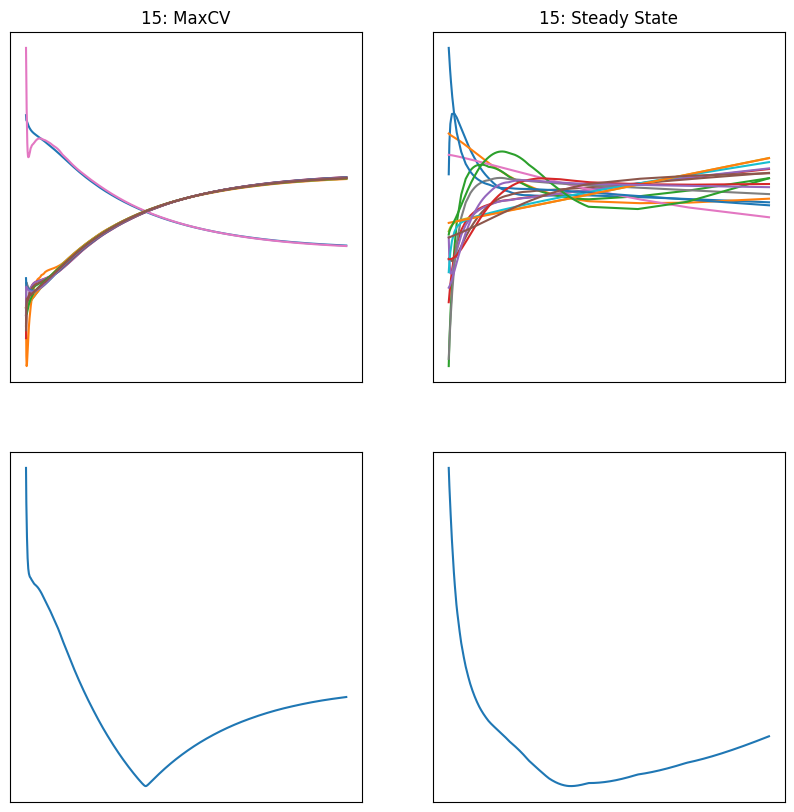

In [4]:
def plotEstimates(model_num: int):
    estimator = CharacteristicTimeEstimator(Model.makeBiomodel(model_num=model_num), timeout=120)
    endtime_maxcv = estimator.detect_cv_maximized()
    endtime_steady = estimator.detect_steadystate()
    # Plots
    _, axes = plt.subplots(2,2, figsize=(10, 10))
    ax_mid_maxcv, ax_bot_maxcv, ax_mid_steady, ax_bot_steady = axes[0, 0], axes[1, 0], axes[0, 1], axes[1, 1]
    # Max cv
    simulator = Simulator(Model.makeBiomodel(model_num=45), start_time=0, end_time=endtime_maxcv, num_point=1000)
    result_df = simulator.simulate().timecourse_df
    estimator.plotStdNrml(end_time=endtime_maxcv, ax_mid=ax_mid_maxcv, ax_bot=ax_bot_maxcv, title="MaxCv", is_label=False)
    ax_mid_maxcv.set_title(f"{model_num}: MaxCV")
    # Steady state
    endtime_steady = endtime_steady if (endtime_steady is not None) else -1
    if endtime_steady > 0:
        simulator = Simulator(Model.makeBiomodel(model_num=45), start_time=0, end_time=endtime_steady, num_point=1000)
        result_df = simulator.simulate().timecourse_df
        estimator.plotStdNrml(end_time=80, ax_mid=ax_mid_steady, ax_bot=ax_bot_steady, title=(f"{model_num}MC"),
                is_label=False)
        ax_mid_steady.set_title(f"{model_num}: Steady State")
    else:
        ax_mid_steady.text(0.5, 0.5, "None")
        ax_mid_steady.set_title(f"{model_num}:SS")

plotEstimates(15)